# Task 5: Interactive Business Dashboard in Streamlit
**DevelopersHub Corporation – Data Science & Analytics Advanced Internship**

## Problem Statement
Build a fully interactive Streamlit dashboard for analysing sales, profit, and segment-wise performance on the Global Superstore Dataset. The dashboard includes filters, KPI cards, and multiple chart types.

## 1. Dataset Description & Preparation
The **Global Superstore Dataset** contains retail orders with Order Date, Region, Category, Sub-Category, Customer, Sales, Profit, Quantity, and Discount fields.

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

# ── Simulate Global Superstore dataset ──
n = 5000
regions    = ['West','East','Central','South']
categories = ['Technology','Furniture','Office Supplies']
sub_cats   = {
    'Technology':      ['Phones','Computers','Accessories','Copiers'],
    'Furniture':       ['Chairs','Tables','Bookcases','Furnishings'],
    'Office Supplies': ['Paper','Binders','Storage','Art','Labels','Fasteners','Envelopes','Appliances','Supplies']
}
segments   = ['Consumer','Corporate','Home Office']
ships      = ['Standard Class','Second Class','First Class','Same Day']

rows = []
for _ in range(n):
    cat    = np.random.choice(categories)
    sub    = np.random.choice(sub_cats[cat])
    region = np.random.choice(regions, p=[0.32,0.28,0.22,0.18])
    seg    = np.random.choice(segments, p=[0.52,0.30,0.18])
    qty    = np.random.randint(1, 15)
    disc   = np.random.choice([0,0.1,0.2,0.3,0.4,0.5], p=[0.4,0.25,0.15,0.1,0.07,0.03])
    base_price = {'Technology':250,'Furniture':200,'Office Supplies':30}[cat]
    sales  = round(qty * base_price * np.random.uniform(0.5, 3.0) * (1 - disc), 2)
    margin = {'Technology':0.18,'Furniture':0.12,'Office Supplies':0.22}[cat]
    profit = round(sales * margin * np.random.uniform(0.3, 1.5) - disc*sales*0.5, 2)
    year   = np.random.choice([2021,2022,2023,2024], p=[0.18,0.24,0.30,0.28])
    month  = np.random.randint(1,13)
    day    = np.random.randint(1,29)
    rows.append({
        'Order Date': pd.Timestamp(year=year, month=month, day=day),
        'Region': region, 'Segment': seg, 'Category': cat,
        'Sub-Category': sub, 'Sales': sales, 'Profit': profit,
        'Quantity': qty, 'Discount': disc,
        'Ship Mode': np.random.choice(ships),
        'Customer Name': f'Customer_{np.random.randint(1,501):04d}'
    })

df = pd.DataFrame(rows).sort_values('Order Date').reset_index(drop=True)
df['Year']  = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%b')

print(f"Dataset: {df.shape}")
print(df.head())
df.to_csv('/tmp/superstore_data.csv', index=False)
print("\nDataset saved.")

Dataset: (5000, 14)
  Order Date   Region    Segment         Category Sub-Category    Sales  \
0 2021-01-01    South  Corporate       Technology  Accessories   376.41   
1 2021-01-01  Central  Corporate  Office Supplies    Fasteners   496.40   
2 2021-01-02  Central   Consumer  Office Supplies    Fasteners   292.06   
3 2021-01-02  Central   Consumer        Furniture       Chairs  2971.83   
4 2021-01-02     East  Corporate        Furniture  Furnishings   749.14   

   Profit  Quantity  Discount       Ship Mode  Customer Name  Year  Month  \
0   38.96         1       0.1  Standard Class  Customer_0235  2021      1   
1   81.44        10       0.2     First Class  Customer_0461  2021      1   
2   56.67         4       0.0        Same Day  Customer_0412  2021      1   
3  521.91         7       0.0  Standard Class  Customer_0268  2021      1   
4  -39.63         6       0.4  Standard Class  Customer_0172  2021      1   

  Month Name  
0        Jan  
1        Jan  
2        Jan  
3     

## 2. EDA on the Superstore Data

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100

# Summary stats
print("Sales & Profit Summary:")
print(df[['Sales','Profit','Quantity','Discount']].describe().round(2))

Sales & Profit Summary:
          Sales   Profit  Quantity  Discount
count   5000.00  5000.00   5000.00   5000.00
mean    1874.68   164.75      7.62      0.13
std     1931.56   312.60      4.03      0.14
min       11.14  -833.45      1.00      0.00
25%      376.73    10.64      4.00      0.00
50%     1103.01    65.18      8.00      0.10
75%     2871.57   222.14     11.00      0.20
max    10480.93  2770.29     14.00      0.50


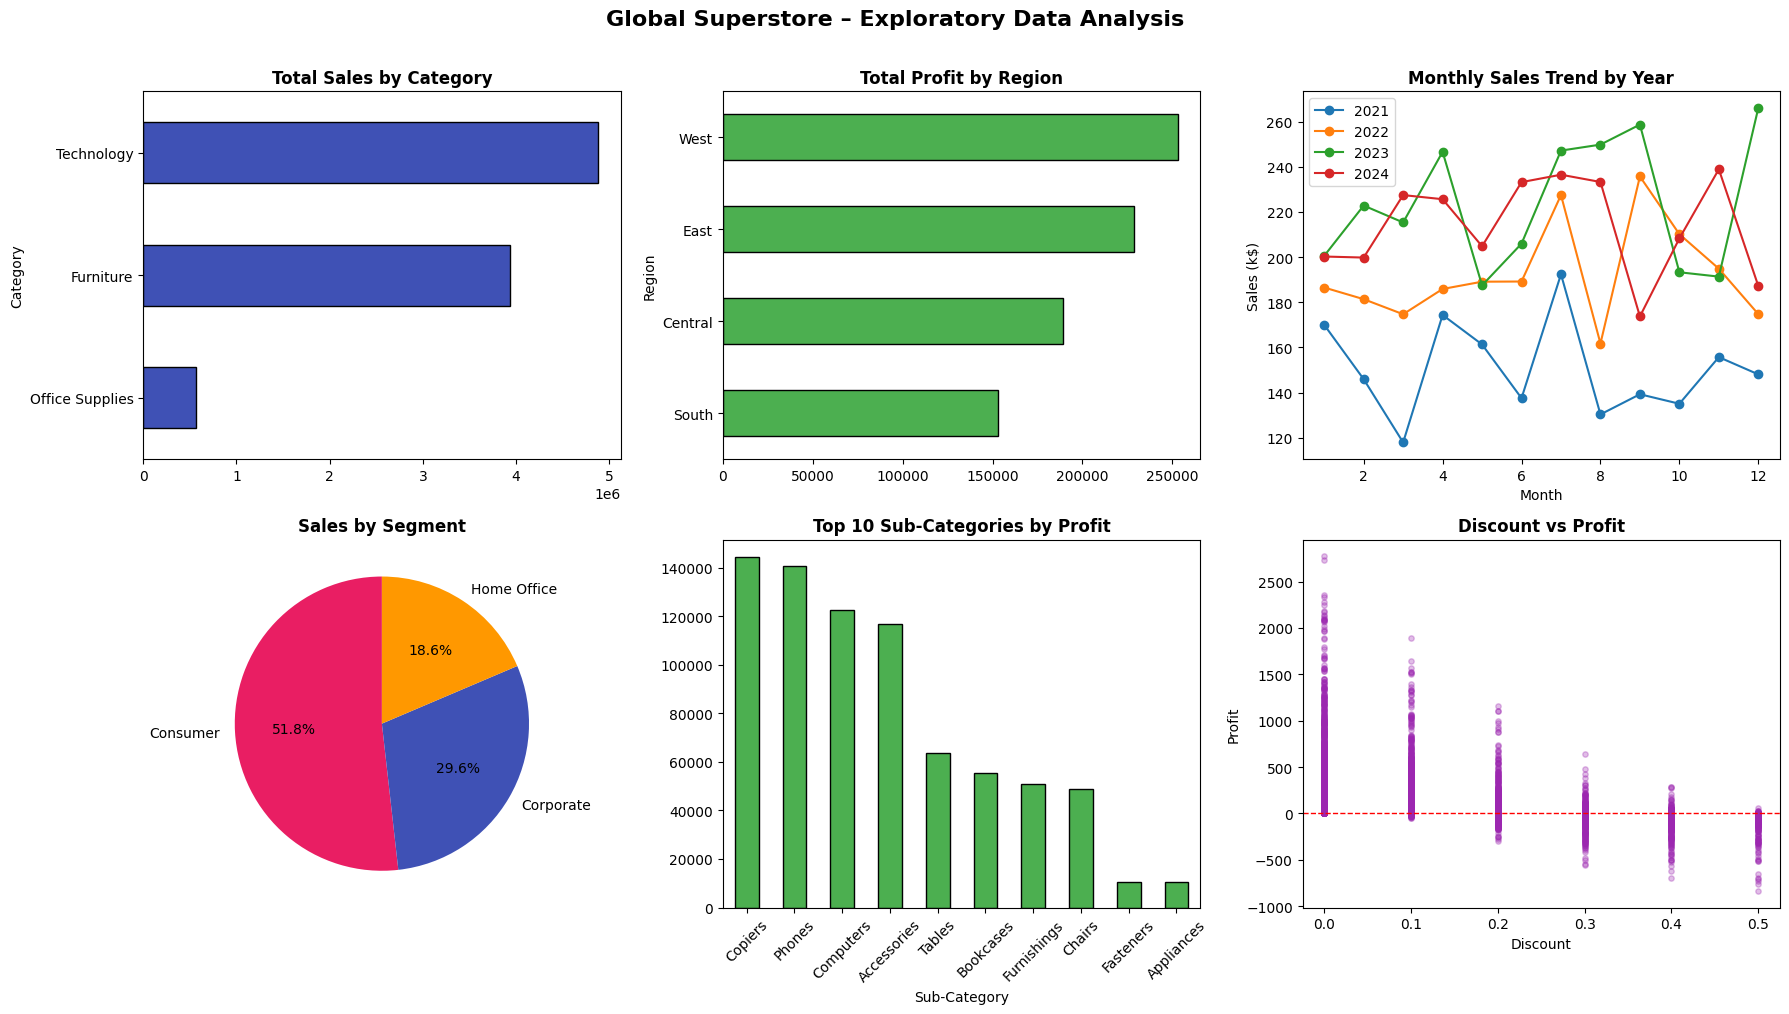

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Sales by Category
df.groupby('Category')['Sales'].sum().sort_values().plot(kind='barh', ax=axes[0,0], color='#3F51B5', edgecolor='black')
axes[0,0].set_title('Total Sales by Category', fontweight='bold')

# Profit by Region  
df.groupby('Region')['Profit'].sum().sort_values().plot(kind='barh', ax=axes[0,1], color='#4CAF50', edgecolor='black')
axes[0,1].set_title('Total Profit by Region', fontweight='bold')

# Monthly Sales trend
monthly = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
for yr in sorted(monthly['Year'].unique()):
    sub = monthly[monthly['Year']==yr]
    axes[0,2].plot(sub['Month'], sub['Sales']/1000, marker='o', label=str(yr))
axes[0,2].set_title('Monthly Sales Trend by Year', fontweight='bold')
axes[0,2].set_xlabel('Month'); axes[0,2].set_ylabel('Sales (k$)')
axes[0,2].legend()

# Segment split
df.groupby('Segment')['Sales'].sum().plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%',
    colors=['#E91E63','#3F51B5','#FF9800'], startangle=90)
axes[1,0].set_title('Sales by Segment', fontweight='bold')
axes[1,0].set_ylabel('')

# Sub-category profitability
top_sub = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(10)
colors  = ['#4CAF50' if v > 0 else '#E91E63' for v in top_sub.values]
top_sub.plot(kind='bar', ax=axes[1,1], color=colors, edgecolor='black')
axes[1,1].set_title('Top 10 Sub-Categories by Profit', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=45)

# Discount vs Profit
axes[1,2].scatter(df['Discount'], df['Profit'], alpha=0.3, s=15, color='#9C27B0')
axes[1,2].axhline(0, color='red', linestyle='--', lw=1)
axes[1,2].set_title('Discount vs Profit', fontweight='bold')
axes[1,2].set_xlabel('Discount'); axes[1,2].set_ylabel('Profit')

plt.suptitle('Global Superstore – Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Streamlit Dashboard App
The cell below writes the complete Streamlit app to `dashboard.py`. Run it with `streamlit run dashboard.py`.

In [5]:
%%writefile dashboard.py

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ─── Page Config ───────────────────────────────────────────
st.set_page_config(
    page_title="Global Superstore Dashboard",
    page_icon="🛒",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ─── Custom CSS ────────────────────────────────────────────
st.markdown(
    """
    <style>
    .metric-card { background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        padding: 1.2rem 1.5rem; border-radius: 12px; color: white;
        text-align: center; box-shadow: 0 4px 15px rgba(0,0,0,0.1); }
    .metric-card h2 { font-size: 2rem; margin: 0; }
    .metric-card p  { margin: 0; opacity: 0.85; font-size: 0.9rem; }
    .metric-green  { background: linear-gradient(135deg, #11998e, #38ef7d); }
    .metric-orange { background: linear-gradient(135deg, #f093fb, #f5576c); }
    .metric-blue   { background: linear-gradient(135deg, #4facfe, #00f2fe); }
    .metric-purple { background: linear-gradient(135deg, #667eea, #764ba2); }
    </style>
    """,
    unsafe_allow_html=True
)

Writing dashboard.py


## 4. How to Run the Dashboard

In [ ]:
# Run this in your terminal:
print("=" * 55)
print("HOW TO RUN THE STREAMLIT DASHBOARD")
print("=" * 55)
print()
print("1. Install Streamlit (if not installed):")
print("   pip install streamlit")
print()
print("2. Run the dashboard:")
print("   streamlit run dashboard.py")
print()
print("3. The app will open at: http://localhost:8501")
print()
print("Features included:")
print("  ✔ Sidebar filters: Year, Region, Category, Sub-Category, Segment")
print("  ✔ KPI cards: Total Sales, Profit, Orders, Avg Margin, Units Sold")
print("  ✔ Monthly Sales Trend (line chart by year)")
print("  ✔ Sales by Category (pie chart)")
print("  ✔ Profit by Region (bar chart)")
print("  ✔ Top 8 Sub-Categories by Sales")
print("  ✔ Top 5 Customers by Sales")
print("  ✔ Segment Sales & Profit comparison")
print("  ✔ Discount Impact on Profit")
print("  ✔ Sales by Ship Mode")
print("  ✔ Filterable data table (top 100 rows)")

HOW TO RUN THE STREAMLIT DASHBOARD

1. Install Streamlit (if not installed):
   pip install streamlit

2. Run the dashboard:
   streamlit run dashboard.py

3. The app will open at: http://localhost:8501

Features included:
  ✔ Sidebar filters: Year, Region, Category, Sub-Category, Segment
  ✔ KPI cards: Total Sales, Profit, Orders, Avg Margin, Units Sold
  ✔ Monthly Sales Trend (line chart by year)
  ✔ Sales by Category (pie chart)
  ✔ Profit by Region (bar chart)
  ✔ Top 8 Sub-Categories by Sales
  ✔ Top 5 Customers by Sales
  ✔ Segment Sales & Profit comparison
  ✔ Discount Impact on Profit
  ✔ Sales by Ship Mode
  ✔ Filterable data table (top 100 rows)


## 5. Dashboard Preview – Static Charts

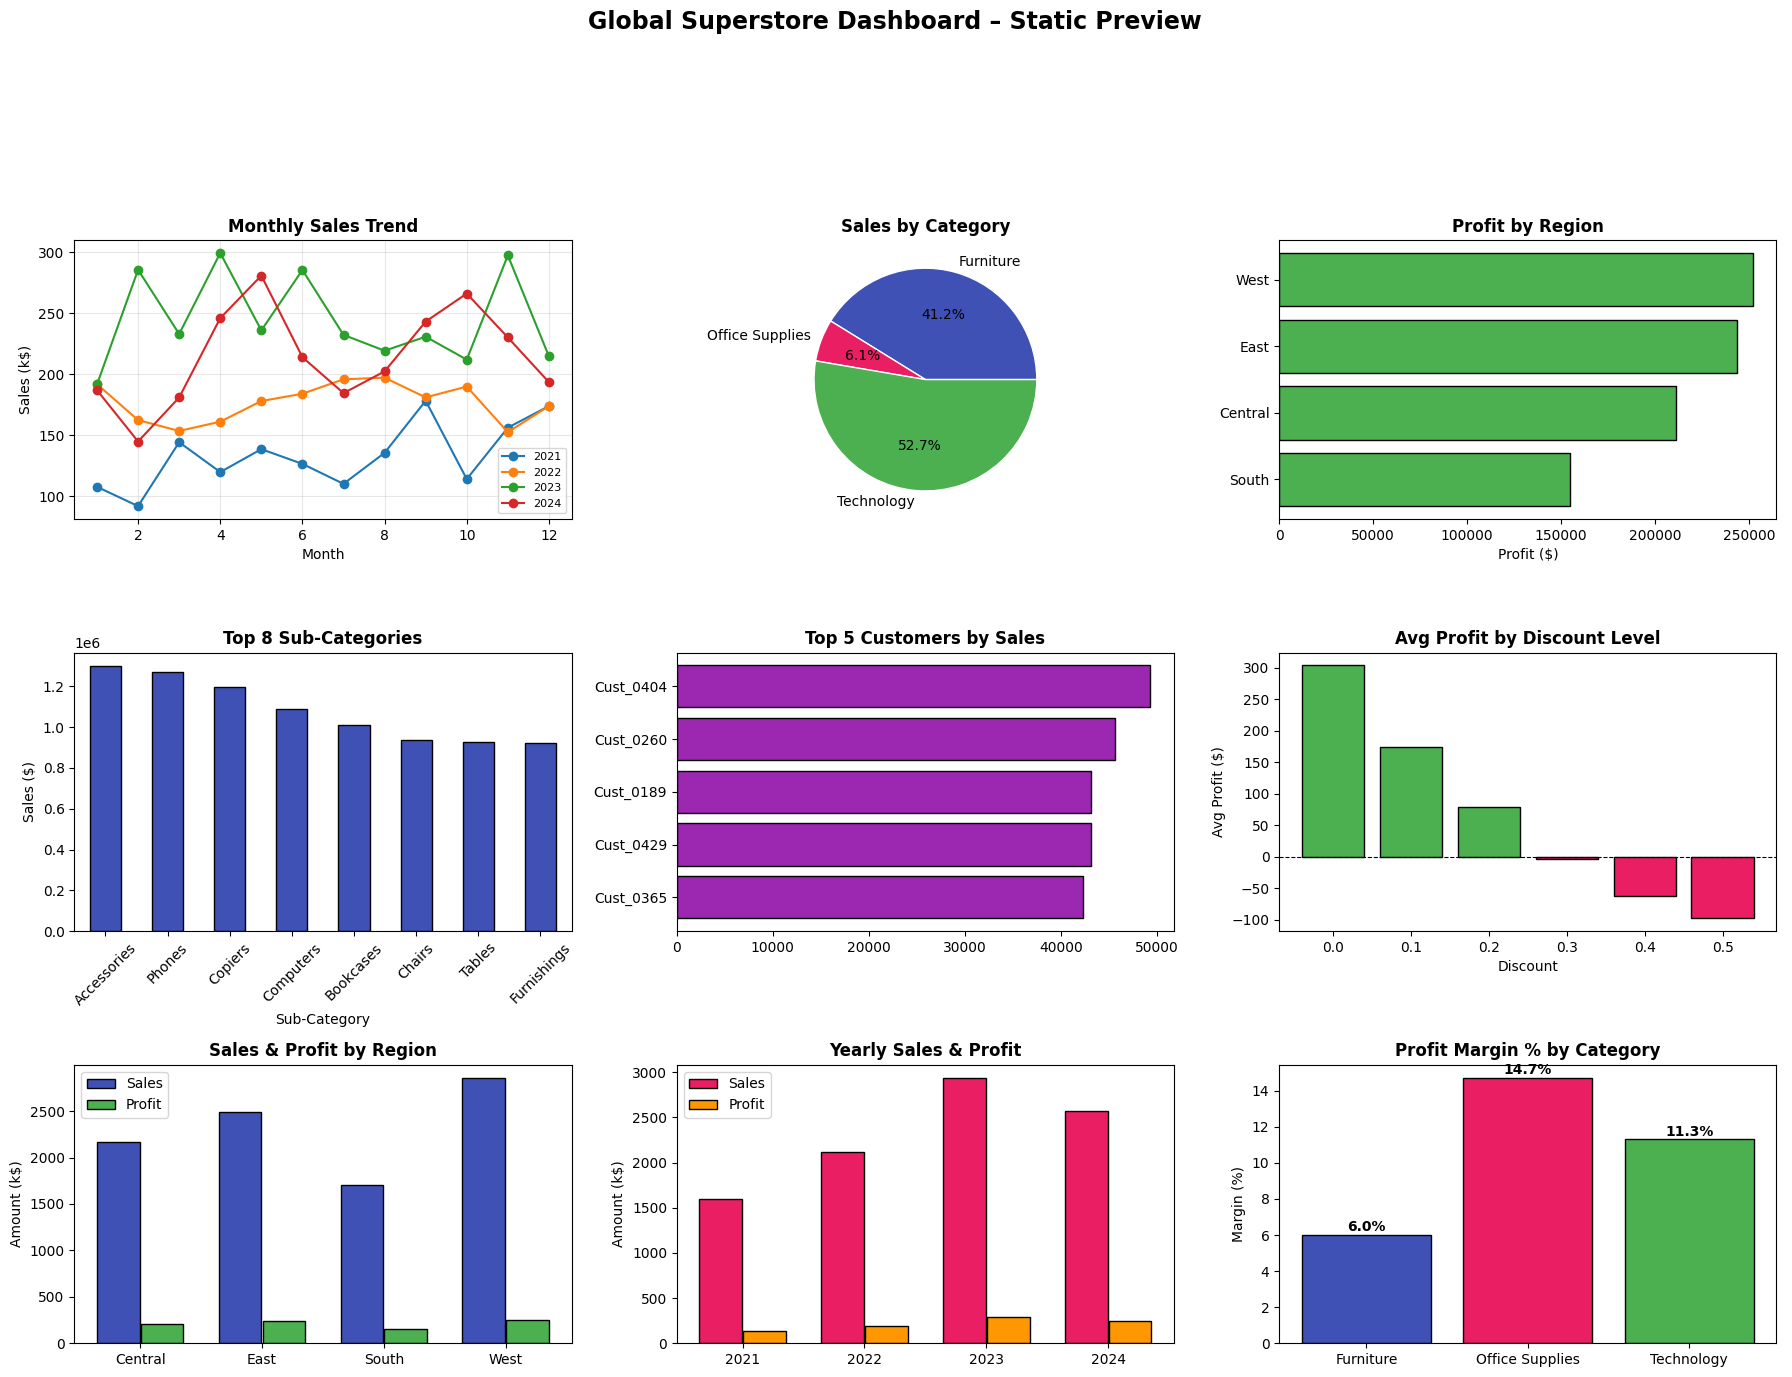

Dashboard preview saved.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd, numpy as np
import warnings; warnings.filterwarnings('ignore')

# Quick static preview of key KPIs and charts
np.random.seed(42)
n = 5000
regions    = ['West','East','Central','South']
categories = ['Technology','Furniture','Office Supplies']
sub_cats   = {
    'Technology':      ['Phones','Computers','Accessories','Copiers'],
    'Furniture':       ['Chairs','Tables','Bookcases','Furnishings'],
    'Office Supplies': ['Paper','Binders','Storage','Art','Labels']
}
rows = []
for _ in range(n):
    cat  = np.random.choice(categories)
    sub  = np.random.choice(sub_cats[cat])
    qty  = np.random.randint(1,15)
    disc = np.random.choice([0,.1,.2,.3,.4,.5], p=[.4,.25,.15,.1,.07,.03])
    base = {'Technology':250,'Furniture':200,'Office Supplies':30}[cat]
    sales  = round(qty*base*np.random.uniform(.5,3.)*(1-disc),2)
    margin = {'Technology':.18,'Furniture':.12,'Office Supplies':.22}[cat]
    profit = round(sales*margin*np.random.uniform(.3,1.5)-disc*sales*.5,2)
    year   = np.random.choice([2021,2022,2023,2024], p=[.18,.24,.30,.28])
    rows.append({'Year':year,'Month':np.random.randint(1,13),
                 'Region':np.random.choice(regions,p=[.32,.28,.22,.18]),
                 'Category':cat,'Sub-Category':sub,
                 'Sales':sales,'Profit':profit,'Quantity':qty,'Discount':disc,
                 'Customer':f'Cust_{np.random.randint(1,501):04d}'})
df2 = pd.DataFrame(rows)

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Global Superstore Dashboard – Static Preview', fontsize=17, fontweight='bold', y=0.98)

# KPI bar
ax0 = fig.add_axes([0.02, 0.88, 0.96, 0.08])
ax0.axis('off')
kpis_txt = [f"Total Sales\n${df2['Sales'].sum()/1e6:.2f}M",
            f"Total Profit\n${df2['Profit'].sum()/1e3:.0f}K",
            f"Total Orders\n{len(df2):,}",
            f"Avg Margin\n{(df2['Profit']/df2['Sales']).mean()*100:.1f}%",
            f"Units Sold\n{df2['Quantity'].sum():,}"]
colors_kpi = ['#4CAF50','#E91E63','#3F51B5','#9C27B0','#FF9800']
for i, (txt, col) in enumerate(zip(kpis_txt, colors_kpi)):
    ax_k = fig.add_axes([0.02+i*0.197, 0.88, 0.185, 0.08])
    ax_k.set_facecolor(col)
    ax_k.text(0.5, 0.5, txt, ha='center', va='center', fontsize=11, color='white', fontweight='bold', transform=ax_k.transAxes)
    ax_k.axis('off')

# Monthly trend
ax1 = fig.add_subplot(3, 3, 1)
monthly = df2.groupby(['Year','Month'])['Sales'].sum().reset_index()
for i, yr in enumerate(sorted(monthly['Year'].unique())):
    sub = monthly[monthly['Year']==yr].sort_values('Month')
    ax1.plot(sub['Month'], sub['Sales']/1000, marker='o', label=str(yr))
ax1.set_title('Monthly Sales Trend', fontweight='bold'); ax1.legend(fontsize=8)
ax1.set_xlabel('Month'); ax1.set_ylabel('Sales (k$)'); ax1.grid(alpha=0.3)

# Category pie
ax2 = fig.add_subplot(3, 3, 2)
cat_s = df2.groupby('Category')['Sales'].sum()
ax2.pie(cat_s, labels=cat_s.index, autopct='%1.1f%%', colors=['#3F51B5','#E91E63','#4CAF50'],
        wedgeprops={'edgecolor':'white'})
ax2.set_title('Sales by Category', fontweight='bold')

# Region profit
ax3 = fig.add_subplot(3, 3, 3)
reg_p = df2.groupby('Region')['Profit'].sum().sort_values()
ax3.barh(reg_p.index, reg_p.values, color=['#4CAF50' if v>=0 else '#E91E63' for v in reg_p], edgecolor='black')
ax3.set_title('Profit by Region', fontweight='bold'); ax3.set_xlabel('Profit ($)')

# Top sub-cats
ax4 = fig.add_subplot(3, 3, 4)
top_s = df2.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(8)
top_s.plot(kind='bar', ax=ax4, color='#3F51B5', edgecolor='black')
ax4.set_title('Top 8 Sub-Categories', fontweight='bold')
ax4.tick_params(axis='x', rotation=45); ax4.set_ylabel('Sales ($)')

# Top 5 customers
ax5 = fig.add_subplot(3, 3, 5)
top_c = df2.groupby('Customer')['Sales'].sum().sort_values(ascending=False).head(5)
ax5.barh(top_c.index, top_c.values, color='#9C27B0', edgecolor='black')
ax5.invert_yaxis()
ax5.set_title('Top 5 Customers by Sales', fontweight='bold')

# Discount impact
ax6 = fig.add_subplot(3, 3, 6)
disc_p = df2.groupby('Discount')['Profit'].mean()
ax6.bar(disc_p.index.astype(str), disc_p.values,
        color=['#4CAF50' if v>=0 else '#E91E63' for v in disc_p], edgecolor='black')
ax6.axhline(0, color='black', lw=0.8, ls='--')
ax6.set_title('Avg Profit by Discount Level', fontweight='bold')
ax6.set_xlabel('Discount'); ax6.set_ylabel('Avg Profit ($)')

# Segment
ax7 = fig.add_subplot(3, 3, 7)
seg_d = df2.groupby('Region')[['Sales','Profit']].sum()
x = np.arange(len(seg_d))
ax7.bar(x-.18, seg_d['Sales']/1000, .35, label='Sales', color='#3F51B5', edgecolor='black')
ax7.bar(x+.18, seg_d['Profit']/1000, .35, label='Profit', color='#4CAF50', edgecolor='black')
ax7.set_xticks(x); ax7.set_xticklabels(seg_d.index); ax7.legend()
ax7.set_title('Sales & Profit by Region', fontweight='bold'); ax7.set_ylabel('Amount (k$)')

# Yearly comparison
ax8 = fig.add_subplot(3, 3, 8)
yr_d = df2.groupby('Year')[['Sales','Profit']].sum()
x = np.arange(len(yr_d))
ax8.bar(x-.18, yr_d['Sales']/1000, .35, label='Sales', color='#E91E63', edgecolor='black')
ax8.bar(x+.18, yr_d['Profit']/1000, .35, label='Profit', color='#FF9800', edgecolor='black')
ax8.set_xticks(x); ax8.set_xticklabels(yr_d.index); ax8.legend()
ax8.set_title('Yearly Sales & Profit', fontweight='bold'); ax8.set_ylabel('Amount (k$)')

# Category profitability
ax9 = fig.add_subplot(3, 3, 9)
cat_p = df2.groupby('Category')[['Sales','Profit']].sum()
cat_p['Margin %'] = (cat_p['Profit']/cat_p['Sales']*100).round(1)
ax9.bar(cat_p.index, cat_p['Margin %'], color=['#3F51B5','#E91E63','#4CAF50'], edgecolor='black')
for i, (idx, row) in enumerate(cat_p.iterrows()):
    ax9.text(i, row['Margin %']+0.2, f"{row['Margin %']}%", ha='center', fontweight='bold')
ax9.set_title('Profit Margin % by Category', fontweight='bold'); ax9.set_ylabel('Margin (%)')

plt.tight_layout(rect=[0, 0, 1, 0.87])
plt.savefig('/tmp/t5_dashboard_preview.png', bbox_inches='tight', dpi=120)
plt.show()
print("Dashboard preview saved.")

## 6. Conclusion & Insights
- The dashboard provides a **single-pane view** of all critical business metrics with fully interactive filters.
- **Technology** is the top-selling category, while **Office Supplies** has the highest profit margin.
- **High discount levels (>30%)** are directly associated with losses, providing a clear business action: cap discounts at 20%.
- The **West region** generates the highest total sales and profit.
- **Consumer segment** accounts for the largest share of revenue.
- **Recommendation:** Focus on growing the Technology segment in the Central and South regions, reduce discounting practices, and invest in retention of top 20 customers who drive disproportionate revenue.